### Analisi di CrowS-Pairs per la costruzione di una tassonomia di termini sensibili

Questo notebook analizza il dataset **CrowS-Pairs** con l’obiettivo di estrarre termini associati a diverse categorie di bias.

La pipeline confronta le coppie di frasi `sent_more` e `sent_less`, pulisce i termini estratti e li organizza in una tassonomia composta da:

- termini diretti;
- termini proxy;
- termini stereotipati;
- altri termini.

L’output finale consiste in due file JSON riutilizzabili nelle fasi successive del progetto.

### Caricamento del dataset

In questa prima fase vengono importate le librerie necessarie e viene caricato il dataset **CrowS-Pairs**.

Il dataset viene letto dal file CSV presente nella cartella `data/` e salvato nella variabile `crows_pairs`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CrowS-Pairs dataset
crows_pairs = pd.read_csv("../data/crows_pairs_anonymized.csv")

print(f"Dataset loaded: {crows_pairs.shape[0]:,} rows × {crows_pairs.shape[1]} columns")

Dataset loaded: 1,508 rows × 8 columns


### Distribuzione delle categorie di bias

Questa cella calcola quanti esempi sono presenti per ogni valore di `bias_type`.

La tabella e il grafico permettono di osservare quali categorie di bias sono più rappresentate nel dataset.

,bias_type,count,percentage
0,race-color,516,34.22%
1,gender,262,17.37%
2,socioeconomic,172,11.41%
3,nationality,159,10.54%
4,religion,105,6.96%
5,age,87,5.77%
6,sexual-orientation,84,5.57%
7,physical-appearance,63,4.18%
8,disability,60,3.98%


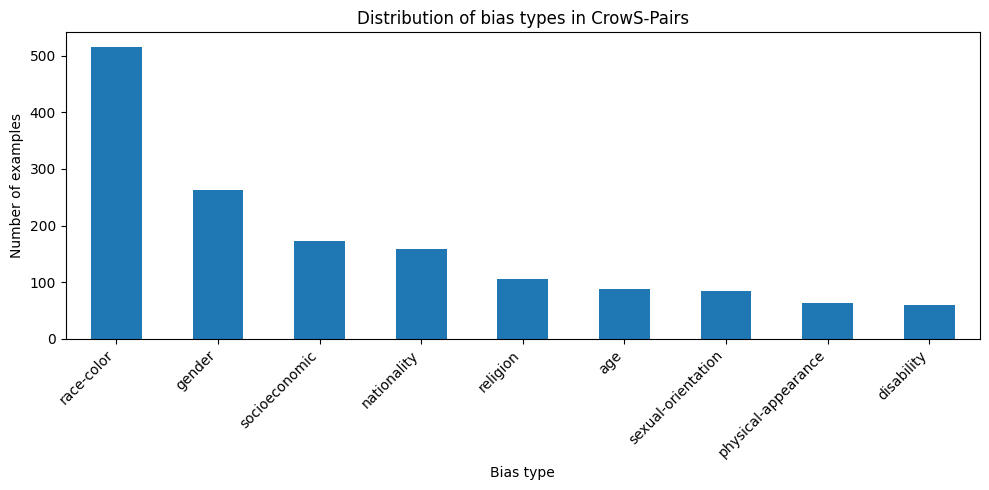

In [9]:
# Count examples by bias type
counts = crows_pairs["bias_type"].value_counts()
percentages = (counts / counts.sum() * 100).round(2)

taxonomy_overview = (
    pd.DataFrame({
        "count": counts,
        "percentage": percentages
    })
    .reset_index()
    .rename(columns={"index": "bias_type"})
)

# Create a display-only version with formatted percentages
taxonomy_overview_display = taxonomy_overview.copy()
taxonomy_overview_display["percentage"] = taxonomy_overview_display["percentage"].astype(str) + "%"

display(taxonomy_overview_display)

# Plot distribution
ax = taxonomy_overview.plot(
    kind="bar",
    x="bias_type",
    y="count",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Distribution of bias types in CrowS-Pairs")
ax.set_xlabel("Bias type")
ax.set_ylabel("Number of examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Estrazione iniziale dei termini differenziali

Questa cella estrae i termini che differiscono tra `sent_more` e `sent_less`.

Per ogni coppia di frasi viene calcolata la differenza simmetrica tra gli insiemi di parole. Il risultato è una prima lista grezza di termini potenzialmente legati ai bias type.

In [10]:
from collections import defaultdict, Counter
import re

def tokenize(text):
    return re.findall(r"\b[\w'-]+\b", text.lower())

feature_terms = defaultdict(list)

for _, row in crows_pairs.iterrows():
    words_more = set(tokenize(row["sent_more"]))
    words_less = set(tokenize(row["sent_less"]))

    diff = words_more.symmetric_difference(words_less)

    feature_terms[row["bias_type"]].extend(diff)

# Collect the 30 most common differential terms for each bias type
top_terms_rows = []

for bias_type, terms in feature_terms.items():
    common_terms = Counter(terms).most_common(30)

    for rank, (term, frequency) in enumerate(common_terms, start=1):
        top_terms_rows.append({
            "bias_type": bias_type,
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

top_feature_terms = pd.DataFrame(top_terms_rows)

display(top_feature_terms)

,bias_type,rank,term,frequency
0,race-color,1,white,258
1,race-color,2,black,208
2,race-color,3,whites,39
3,race-color,4,american,31
4,race-color,5,blacks,30
...,...,...,...,...
265,age,26,woman,1
266,age,27,water,1
267,age,28,waterpark,1
268,age,29,park,1


### Separazione dei termini tra `sent_more` e `sent_less`

Questa cella separa i termini in base al lato della coppia in cui compaiono.

I termini presenti solo in `sent_more` vengono salvati in `terms_more`, mentre quelli presenti solo in `sent_less` vengono salvati in `terms_less`.

In [11]:
def tokenize(text):
    return re.findall(r"\b[\w'-]+\b", text.lower())

terms_more = defaultdict(list)
terms_less = defaultdict(list)

for _, row in crows_pairs.iterrows():
    words_more = set(tokenize(row["sent_more"]))
    words_less = set(tokenize(row["sent_less"]))

    only_more = words_more - words_less
    only_less = words_less - words_more

    bias_type = row["bias_type"]

    terms_more[bias_type].extend(only_more)
    terms_less[bias_type].extend(only_less)

# Build a readable table with the most frequent terms appearing only in sent_more or sent_less
terms_direction_rows = []

for bias_type in terms_more.keys():
    more_common_terms = Counter(terms_more[bias_type]).most_common(30)
    less_common_terms = Counter(terms_less[bias_type]).most_common(30)

    for rank, (term, frequency) in enumerate(more_common_terms, start=1):
        terms_direction_rows.append({
            "bias_type": bias_type,
            "sentence_side": "sent_more",
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

    for rank, (term, frequency) in enumerate(less_common_terms, start=1):
        terms_direction_rows.append({
            "bias_type": bias_type,
            "sentence_side": "sent_less",
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

terms_by_sentence_side = pd.DataFrame(terms_direction_rows)

display(terms_by_sentence_side)

,bias_type,sentence_side,rank,term,frequency
0,race-color,sent_more,1,black,194
1,race-color,sent_more,2,blacks,29
2,race-color,sent_more,3,african,24
3,race-color,sent_more,4,white,15
4,race-color,sent_more,5,jamal,13
...,...,...,...,...,...
535,age,sent_less,26,same,1
536,age,sent_less,27,18,1
537,age,sent_less,28,granddaughter,1
538,age,sent_less,29,great,1


### Definizione di stop words e normalizzazioni manuali

Questa cella definisce due risorse usate per pulire i termini estratti.

`stop_words` contiene parole frequenti ma poco informative.  
`manual_map` normalizza varianti lessicali, plurali e forme inconsistenti in una forma canonica.

In [12]:
# Stop words and dataset-specific noisy tokens to remove during term extraction.
# These terms are filtered out because they are frequent but not informative
# for identifying sensitive features or bias-related terms.

stop_words = {
    "a", "an", "the", "and", "or", "of", "to", "in", "on", "with",
    "for", "from", "at", "by", "that", "this", "is", "are", "was",
    "were", "be", "been", "being", "have", "has", "had", "do", "does",
    "did", "not", "no", "his", "her", "he", "she", "him",
    "could", "couldn't", "weren't", "haven't", "wasn't",
    "never", "always", "just", "more", "much", "so",
    "but", "as", "t", "all", "their", "people", "don't", "didn't",
    "hand", "everyone", "two", "less", "begin", "yet", "my",
    "great", "friends", "similar", "baseball", "projects", "full"
}

# Manual normalization map.
# It maps plural forms, spelling variants, and dataset-specific variants
# to a canonical form used in the extracted lexicon.

manual_map = {
    "blacks": "black",
    "whites": "white",
    "americans": "american",
    "african-americans": "african-american",
    "afro-american": "african-american",
    "asians": "asian",
    "latinos": "latino",
    "mexicans": "mexican",
    "christians": "christian",
    "muslims": "muslim",
    "jews": "jew",
    "heterosexuals": "heterosexual",
    "homosexuals": "homosexual",
    "lesbians": "lesbian",
    "gays": "gay",
    "immigrants": "immigrant",
    "teenagers": "teenager",
    "adults": "adult",
    "children": "child",
    "seniors": "senior",
    "asian-americans": "asian-american",
    "indians": "indian",
    "italians": "italian",
    "foreigners": "foreigner",
    "atheists": "atheist",
    "catholics": "catholic",
    "baptists": "baptist",
    "satanists": "satanist",
    "episcopalians": "episcopalian",
    "straights": "straight",
    "hetrosexual": "heterosexual",
    "hetrosexuals": "heterosexual",
    "etero": "heterosexual",
    "fatties": "fat",
    "retards": "retard"
}

# Quick sanity check
normalization_summary = pd.DataFrame({
    "resource": ["stop_words", "manual_map"],
    "size": [len(stop_words), len(manual_map)]
})

display(normalization_summary)

,resource,size
0,stop_words,68
1,manual_map,35


### Tokenizzazione pulita

La funzione `tokenize_clean` tokenizza il testo, applica le normalizzazioni definite in `manual_map` e rimuove le parole presenti in `stop_words`.

Questa funzione viene usata per ripetere l’estrazione dei termini su una versione più pulita del testo.

In [13]:
def tokenize_clean(text):
    """
    Tokenize text, normalize selected tokens using manual_map,
    and remove stop words / noisy tokens.
    """
    tokens = re.findall(r"\b[\w'-]+\b", text.lower())

    cleaned = []
    for token in tokens:
        token = manual_map.get(token, token)

        if token in stop_words:
            continue

        cleaned.append(token)

    return cleaned

### Estrazione dei termini dopo la pulizia

Dopo aver definito `tokenize_clean`, l’estrazione viene ripetuta usando il testo pulito.

Anche in questo caso i termini vengono separati tra quelli presenti solo in `sent_more` e quelli presenti solo in `sent_less`.

In [14]:
terms_more = defaultdict(list)
terms_less = defaultdict(list)

for _, row in crows_pairs.iterrows():
    words_more = set(tokenize_clean(row["sent_more"]))
    words_less = set(tokenize_clean(row["sent_less"]))

    only_more = words_more - words_less
    only_less = words_less - words_more

    bias_type = row["bias_type"]

    terms_more[bias_type].extend(only_more)
    terms_less[bias_type].extend(only_less)

# Build a readable table with the most frequent cleaned terms
# appearing only in sent_more or only in sent_less.
clean_terms_rows = []

for bias_type in terms_more.keys():
    more_common_terms = Counter(terms_more[bias_type]).most_common(30)
    less_common_terms = Counter(terms_less[bias_type]).most_common(30)

    for rank, (term, frequency) in enumerate(more_common_terms, start=1):
        clean_terms_rows.append({
            "bias_type": bias_type,
            "sentence_side": "sent_more",
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

    for rank, (term, frequency) in enumerate(less_common_terms, start=1):
        clean_terms_rows.append({
            "bias_type": bias_type,
            "sentence_side": "sent_less",
            "rank": rank,
            "term": term,
            "frequency": frequency
        })

clean_terms_by_sentence_side = pd.DataFrame(clean_terms_rows)

display(clean_terms_by_sentence_side)

,bias_type,sentence_side,rank,term,frequency
0,race-color,sent_more,1,black,221
1,race-color,sent_more,2,african,24
2,race-color,sent_more,3,african-american,19
3,race-color,sent_more,4,white,17
4,race-color,sent_more,5,asian,15
...,...,...,...,...,...
525,age,sent_less,26,40s,1
526,age,sent_less,27,five,1
527,age,sent_less,28,senior,1
528,age,sent_less,29,business,1


### Statistiche aggregate dei termini

Questa cella combina i conteggi dei termini presenti in `sent_more` e `sent_less`.

Per ogni termine vengono calcolati il numero di occorrenze nei due lati della coppia, la frequenza totale e la differenza tra i conteggi.

In [15]:
# Merge sent_more and sent_less term counts into a single readable table.
# For each bias type, we compute:
# - more_count: occurrences only in sent_more
# - less_count: occurrences only in sent_less
# - total_count: total occurrences across both sides
# - difference: more_count - less_count

merged_term_rows = []

for bias_type in terms_more.keys():
    counter_more = Counter(terms_more[bias_type])
    counter_less = Counter(terms_less[bias_type])

    all_terms = set(counter_more.keys()).union(counter_less.keys())

    rows = []
    for term in all_terms:
        c_more = counter_more[term]
        c_less = counter_less[term]
        c_total = c_more + c_less
        diff = c_more - c_less

        rows.append((term, c_more, c_less, c_total, diff))

    # Keep the original sorting logic:
    # terms with the highest total frequency appear first.
    rows = sorted(rows, key=lambda x: abs(x[3]), reverse=True)

    for rank, (term, c_more, c_less, c_total, diff) in enumerate(rows[:30], start=1):
        merged_term_rows.append({
            "bias_type": bias_type,
            "rank": rank,
            "term": term,
            "more_count": c_more,
            "less_count": c_less,
            "total_count": c_total,
            "difference": diff
        })

merged_terms_summary = pd.DataFrame(merged_term_rows)

display(merged_terms_summary)

,bias_type,rank,term,more_count,less_count,total_count,difference
0,race-color,1,white,17,278,295,-261
1,race-color,2,black,221,15,236,206
2,race-color,3,american,15,34,49,-19
3,race-color,4,african,24,6,30,18
4,race-color,5,asian,15,8,23,7
...,...,...,...,...,...,...,...
265,age,26,daughter,1,0,1,1
266,age,27,than,1,0,1,1
267,age,28,under,1,0,1,1
268,age,29,five,0,1,1,-1


### Risorse manuali per la classificazione dei termini

Questa cella definisce le risorse manuali usate per classificare i termini estratti.

I termini vengono organizzati in tre categorie principali: `DIRECT_TERMS`, `PROXY_TERMS` e `STEREOTYPE_TERMS`.  
Viene inoltre definito `bias_specific_noise`, usato per filtrare rumore specifico per alcune categorie di bias.

In [17]:
# ---------------------------------------------------------------------
# Stop words and bias-specific noise
# ---------------------------------------------------------------------
# Generic stop words are removed from all bias types.
# Bias-specific noise terms are removed only for selected bias categories,
# when they are frequent but not informative for that specific bias type.

stop_words = {
    "a", "an", "the", "and", "or", "of", "to", "in", "on", "with",
    "for", "from", "at", "by", "that", "this", "is", "are", "was",
    "were", "be", "been", "being", "have", "has", "had", "do", "does",
    "did", "not", "no",
    "could", "couldn't", "weren't", "haven't", "wasn't",
    "never", "always", "just", "more", "much", "so",
    "but", "as", "t", "all", "their", "people", "don't", "didn't",
    "hand", "everyone", "two", "less", "begin", "yet", "my",
    "great", "friends", "similar", "baseball", "projects", "full"
}

bias_specific_noise = {
    "race-color": set(),
    "gender": set(),
    "religion": {"white", "american"},
    "disability": {"white", "man", "smart", "stupid"},
    "sexual-orientation": {"white", "man", "woman", "men", "women", "wife", "husband"},
    "socioeconomic": {"white", "man", "doctor", "lawyer", "police", "businessman"},
    "nationality": {"middle", "new"},
    "physical-appearance": {"yet"},
    "age": {"man", "woman", "men", "boy", "healthy", "great", "similar"}
}

# ---------------------------------------------------------------------
# Manually curated term categories
# ---------------------------------------------------------------------
# DIRECT_TERMS: explicit mentions of sensitive attributes or social groups.
# PROXY_TERMS: indirect indicators, such as names, places, roles, or related entities.
# STEREOTYPE_TERMS: terms that may encode stereotypical associations in the dataset.

DIRECT_TERMS = {
    "race-color": {
        "black", "white", "asian", "caucasian", "african",
        "african-american", "hispanic", "latino"
    },

    "gender": {
        "he", "she", "him", "her", "his",
        "man", "woman", "men", "women",
        "male", "female", "boy", "girl", "boys", "girls",
        "trans", "cis"
    },

    "religion": {
        "christian", "muslim", "jew", "jewish", "hindu",
        "atheist", "catholic", "buddhist", "baptist",
        "wiccan", "mormon", "lutheran", "methodist",
        "episcopalian"
    },

    "age": {
        "young", "old", "elderly", "teenager", "adult",
        "senior", "child", "teenage", "older",
        "middle-aged", "aged", "minor", "minors"
    },

    "sexual-orientation": {
        "gay", "straight", "heterosexual", "homosexual",
        "lesbian", "bisexual"
    },

    "nationality": {
        "american", "mexican", "italian", "chinese", "indian",
        "russian", "canadian", "japanese", "german", "british",
        "armenian", "arab", "korean", "english", "european"
    },

    "disability": {
        "disabled", "autistic", "wheelchair", "handicapped",
        "dyslexia", "palsy", "syndrome", "mental"
    },

    "physical-appearance": {
        "fat", "overweight", "thin", "skinny", "short", "tall",
        "obese", "slim", "beautiful", "ugly", "muscular",
        "fit", "handsome", "underweight"
    },

    "socioeconomic": {
        "poor", "rich", "wealthy", "homeless",
        "poverty", "low", "low-income", "upper-class"
    }
}

PROXY_TERMS = {
    "race-color": {
        "jamal", "tyrone", "jerome", "shaniqua", "laquisha",
        "jose", "juan", "chen", "lee", "lebron"
    },

    "gender": {
        "mary", "sarah", "jenny", "jennifer", "susan", "susie",
        "marie", "lisa", "judy",
        "tom", "john", "carl", "bill", "jim", "joe", "brad"
    },

    "socioeconomic": {
        "doctor", "lawyer", "businessman",
        "janitor", "cashier", "worker", "laborer",
        "construction", "officer", "cops", "police"
    },

    "nationality": {
        "immigrant", "foreigner", "citizen", "citizens"
    },

    "religion": {
        "church", "mosque", "bible", "torah", "shrine"
    },

    "sexual-orientation": {
        "wife", "husband", "boyfriend", "girlfriend",
        "pride", "openly"
    }
}

STEREOTYPE_TERMS = {
    "socioeconomic": {
        "ghetto", "trailer", "projects", "gang",
        "uneducated", "educated", "successful",
        "posh", "stricken", "meager"
    },

    "disability": {
        "retarded", "retard", "crippled",
        "smart", "stupid", "gifted", "normal"
    },

    "physical-appearance": {
        "monstrous", "disfigured", "hunchback"
    },

    "sexual-orientation": {
        "perverted", "butches"
    }
}

# ---------------------------------------------------------------------
# Tokenization and term classification utilities
# ---------------------------------------------------------------------

def tokenize_clean(text, bias_type=None):
    """
    Tokenize text, normalize selected tokens using manual_map,
    remove generic stop words, and optionally remove bias-specific noise.
    """
    tokens = re.findall(r"\b[\w'-]+\b", text.lower())

    cleaned = []
    for token in tokens:
        token = manual_map.get(token, token)

        if token in stop_words:
            continue

        if bias_type is not None and token in bias_specific_noise.get(bias_type, set()):
            continue

        cleaned.append(token)

    return cleaned


def classify_term(term, bias_type):
    """
    Classify a term as direct, proxy, stereotype, or other
    for a given bias type.
    """
    if term in DIRECT_TERMS.get(bias_type, set()):
        return "direct"

    if term in PROXY_TERMS.get(bias_type, set()):
        return "proxy"

    if term in STEREOTYPE_TERMS.get(bias_type, set()):
        return "stereotype"

    return "other"


# Quick sanity check for manually defined resources.
manual_resources_summary = pd.DataFrame({
    "resource": [
        "stop_words",
        "bias_specific_noise",
        "DIRECT_TERMS",
        "PROXY_TERMS",
        "STEREOTYPE_TERMS"
    ],
    "scope": [
        "global",
        "bias-specific",
        "bias-specific",
        "bias-specific",
        "bias-specific"
    ],
    "num_bias_types": [
        "-",
        len(bias_specific_noise),
        len(DIRECT_TERMS),
        len(PROXY_TERMS),
        len(STEREOTYPE_TERMS)
    ],
    "num_terms": [
        len(stop_words),
        sum(len(v) for v in bias_specific_noise.values()),
        sum(len(v) for v in DIRECT_TERMS.values()),
        sum(len(v) for v in PROXY_TERMS.values()),
        sum(len(v) for v in STEREOTYPE_TERMS.values())
    ]
})

display(manual_resources_summary)

,resource,scope,num_bias_types,num_terms
0,stop_words,global,-,63
1,bias_specific_noise,bias-specific,9,29
2,DIRECT_TERMS,bias-specific,9,103
3,PROXY_TERMS,bias-specific,6,52
4,STEREOTYPE_TERMS,bias-specific,4,22


### Estrazione con cleaning specifico per bias type

L’estrazione viene ripetuta passando anche il `bias_type` alla funzione `tokenize_clean`.

Questo permette di rimuovere termini considerati rumore solo per specifiche categorie di bias, mantenendo invece gli stessi termini quando sono rilevanti in altre categorie.

In [18]:
terms_more = defaultdict(list)
terms_less = defaultdict(list)

# Recompute differential terms using bias-specific cleaning.
# Compared to the previous extraction, tokenize_clean now receives the bias_type,
# so it can remove noise terms that are only uninformative for specific categories.
for _, row in crows_pairs.iterrows():
    bias_type = row["bias_type"]

    words_more = set(tokenize_clean(row["sent_more"], bias_type))
    words_less = set(tokenize_clean(row["sent_less"], bias_type))

    only_more = words_more - words_less
    only_less = words_less - words_more

    terms_more[bias_type].extend(only_more)
    terms_less[bias_type].extend(only_less)

### Classificazione dei termini estratti

Questa cella classifica ogni termine estratto tramite la funzione `classify_term`.

Ogni termine viene assegnato a una delle categorie: `direct`, `proxy`, `stereotype` oppure `other`.  
La tabella finale permette di analizzare i termini per bias type, frequenza e ruolo semantico.

In [19]:
classified_term_rows = []

for bias_type in terms_more.keys():
    counter_more = Counter(terms_more[bias_type])
    counter_less = Counter(terms_less[bias_type])

    all_terms = set(counter_more.keys()).union(counter_less.keys())

    rows = []
    for term in all_terms:
        c_more = counter_more[term]
        c_less = counter_less[term]
        c_total = c_more + c_less
        diff = c_more - c_less

        term_type = classify_term(term, bias_type)

        rows.append((term, c_more, c_less, c_total, diff, term_type))

    rows = sorted(rows, key=lambda x: (x[3], abs(x[4])), reverse=True)

    for rank, (term, c_more, c_less, c_total, diff, term_type) in enumerate(rows[:30], start=1):
        classified_term_rows.append({
            "bias_type": bias_type,
            "view": "top_terms",
            "rank": rank,
            "term": term,
            "more_count": c_more,
            "less_count": c_less,
            "total_count": c_total,
            "difference": diff,
            "term_type": term_type
        })

    for target_type in ["direct", "proxy", "stereotype"]:
        filtered_rows = [
            row for row in rows
            if row[5] == target_type
        ]

        for rank, (term, c_more, c_less, c_total, diff, term_type) in enumerate(filtered_rows[:20], start=1):
            classified_term_rows.append({
                "bias_type": bias_type,
                "view": f"{target_type}_terms",
                "rank": rank,
                "term": term,
                "more_count": c_more,
                "less_count": c_less,
                "total_count": c_total,
                "difference": diff,
                "term_type": term_type
            })

classified_terms_summary = pd.DataFrame(classified_term_rows)

display(classified_terms_summary)

,bias_type,view,rank,term,more_count,less_count,total_count,difference,term_type
0,race-color,top_terms,1,white,17,278,295,-261,direct
1,race-color,top_terms,2,black,221,15,236,206,direct
2,race-color,top_terms,3,american,15,34,49,-19,other
3,race-color,top_terms,4,african,24,6,30,18,direct
4,race-color,top_terms,5,asian,15,8,23,7,direct
...,...,...,...,...,...,...,...,...,...
429,age,direct_terms,8,older,3,0,3,3,direct
430,age,direct_terms,9,senior,2,1,3,1,direct
431,age,direct_terms,10,teenage,2,0,2,2,direct
432,age,direct_terms,11,middle-aged,0,2,2,-2,direct


### Esportazione del lessico completo

Questa cella costruisce il lessico completo dei termini estratti.

Per ogni `bias_type`, i termini vengono separati in `direct_terms`, `proxy_terms`, `stereotype_terms` e `other_terms`.  
Per ogni termine vengono salvate anche le statistiche di frequenza.

In [20]:
import json

bias_lexicon = {
    "source_dataset": "CrowS-Pairs",
    "version": "v1",
    "features": {}
}

for bias_type in terms_more.keys():
    counter_more = Counter(terms_more[bias_type])
    counter_less = Counter(terms_less[bias_type])
    all_terms = set(counter_more.keys()).union(counter_less.keys())

    bias_lexicon["features"][bias_type] = {
        "direct_terms": [],
        "proxy_terms": [],
        "stereotype_terms": [],
        "other_terms": []
    }

    for term in all_terms:
        term_type = classify_term(term, bias_type)

        entry = {
            "term": term,
            "more": counter_more[term],
            "less": counter_less[term],
            "total": counter_more[term] + counter_less[term],
            "diff": counter_more[term] - counter_less[term]
        }

        if term_type == "direct":
            bias_lexicon["features"][bias_type]["direct_terms"].append(entry)
        elif term_type == "proxy":
            bias_lexicon["features"][bias_type]["proxy_terms"].append(entry)
        elif term_type == "stereotype":
            bias_lexicon["features"][bias_type]["stereotype_terms"].append(entry)
        else:
            bias_lexicon["features"][bias_type]["other_terms"].append(entry)

output_path = "../outputs/lexicons/bias_lexicon_crows_pairs.json"

with open(output_path, "w") as f:
    json.dump(bias_lexicon, f, indent=2)

# Summarize saved lexicon
bias_lexicon_summary = []

for bias_type, feature_data in bias_lexicon["features"].items():
    bias_lexicon_summary.append({
        "bias_type": bias_type,
        "direct_terms": len(feature_data["direct_terms"]),
        "proxy_terms": len(feature_data["proxy_terms"]),
        "stereotype_terms": len(feature_data["stereotype_terms"]),
        "other_terms": len(feature_data["other_terms"]),
        "total_terms": (
            len(feature_data["direct_terms"])
            + len(feature_data["proxy_terms"])
            + len(feature_data["stereotype_terms"])
            + len(feature_data["other_terms"])
        )
    })

bias_lexicon_summary = pd.DataFrame(bias_lexicon_summary)

print(f"Full lexicon saved to: {output_path}")
display(bias_lexicon_summary)

Full lexicon saved to: ../outputs/lexicons/bias_lexicon_crows_pairs.json


,bias_type,direct_terms,proxy_terms,stereotype_terms,other_terms,total_terms
0,race-color,8,10,0,288,306
1,socioeconomic,6,7,9,156,178
2,gender,17,15,0,186,218
3,disability,8,0,5,59,72
4,nationality,15,4,0,129,148
5,sexual-orientation,6,4,2,29,41
6,physical-appearance,14,0,3,53,70
7,religion,14,5,0,33,52
8,age,12,0,0,59,71


### Esportazione del lessico leggero

Questa cella costruisce una versione compatta del lessico.

Il file leggero contiene solo le liste di termini classificati come `direct`, `proxy` e `stereotype`, senza le statistiche di frequenza.  
Questa versione è più semplice da riutilizzare nelle fasi successive del progetto.

In [22]:
bias_lexicon_light = {
    "source_dataset": "CrowS-Pairs",
    "features": {}
}

for bias_type in terms_more.keys():
    counter_more = Counter(terms_more[bias_type])
    counter_less = Counter(terms_less[bias_type])

    all_terms = set(counter_more.keys()).union(counter_less.keys())

    bias_lexicon_light["features"][bias_type] = {
        "direct": [],
        "proxy": [],
        "stereotype": []
    }

    for term in all_terms:
        term_type = classify_term(term, bias_type)

        if term_type == "direct":
            bias_lexicon_light["features"][bias_type]["direct"].append(term)
        elif term_type == "proxy":
            bias_lexicon_light["features"][bias_type]["proxy"].append(term)
        elif term_type == "stereotype":
            bias_lexicon_light["features"][bias_type]["stereotype"].append(term)

# Sort and deduplicate terms alphabetically for readability.
for bias_type in bias_lexicon_light["features"]:
    for t in ["direct", "proxy", "stereotype"]:
        bias_lexicon_light["features"][bias_type][t] = sorted(
            list(set(bias_lexicon_light["features"][bias_type][t]))
        )

output_path_light = "../outputs/lexicons/bias_lexicon_crows_pairs_light.json"

with open(output_path_light, "w") as f:
    json.dump(bias_lexicon_light, f, indent=2)

# Summarize saved light lexicon
bias_lexicon_light_summary = []

for bias_type, feature_data in bias_lexicon_light["features"].items():
    bias_lexicon_light_summary.append({
        "bias_type": bias_type,
        "direct": len(feature_data["direct"]),
        "proxy": len(feature_data["proxy"]),
        "stereotype": len(feature_data["stereotype"]),
        "total_terms": (
            len(feature_data["direct"])
            + len(feature_data["proxy"])
            + len(feature_data["stereotype"])
        )
    })

bias_lexicon_light_summary = pd.DataFrame(bias_lexicon_light_summary)

print(f"Light lexicon saved to: {output_path_light}")
display(bias_lexicon_light_summary)

Light lexicon saved to: ../outputs/lexicons/bias_lexicon_crows_pairs_light.json


,bias_type,direct,proxy,stereotype,total_terms
0,race-color,8,10,0,18
1,socioeconomic,6,7,9,22
2,gender,17,15,0,32
3,disability,8,0,5,13
4,nationality,15,4,0,19
5,sexual-orientation,6,4,2,12
6,physical-appearance,14,0,3,17
7,religion,14,5,0,19
8,age,12,0,0,12


### Risultato finale

Il notebook produce due file JSON nella cartella `outputs/lexicons/`:

- `bias_lexicon_crows_pairs.json`: lessico completo con termini e statistiche;
- `bias_lexicon_crows_pairs_light.json`: lessico compatto con sole liste di termini.